In [1]:
from util import * 
import matplotlib.pyplot as plt 
import h5py

In [2]:
# Loading the data 
with h5py.File("data/highfi_so.h5", "r") as f: 
    y1 = f['output'][:] / 1e4
    X1 = f['input'][:]

with h5py.File("data/lowfi_grid_so.h5", "r") as f:
    y2 = (f['output'][:] / 1e4)
    X2 = f['input'][:]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X1 = scaler.fit_transform(X1)
X2 = scaler.transform(X2)

print(np.corrcoef(y1, y2))

[[1.         0.99994203]
 [0.99994203 1.        ]]


Calibrated white noise variance: 1.0000e-01


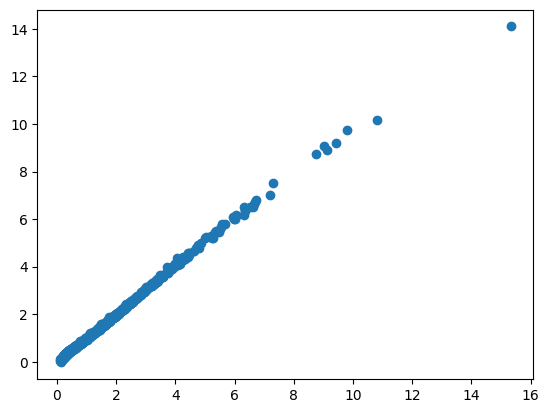

In [143]:
g1 = GP(
    X2,
    y2, 
    RBF, 
    Linear, 
    max_cond = 1e4,
    noise_var = 1e-1, 
    epsilon = 1e-8,
    calibrate=True
)

g1.set_params({
    'k_param':jnp.array([ 4.59231452, 43.95540278, 35.09650143, 50.45847542, 35.22865931]),
    'm_param':jnp.array([16.18080834,  1.81933239,  0.88989751,  3.8881497 ,  4.22606805]),
    'noise_var':jnp.array(-5.93549041)
})

y2_hat, _ = g1.predict(X1, full_cov = False)
plt.scatter(y2, y2_hat)

In [141]:
optimizer = ADAM(g1, neg_mll, beta1=0.9, beta2=0.999)
optimizer.run(1e-1, 1000, ['k_param', 'noise_var', 'm_param'])

100%|██████████| 1000/1000 [00:58<00:00, 17.14it/s, Loss: -1.0945e+02]


{'k_param': Array([ 4.59231452, 43.95540278, 35.09650143, 50.45847542, 35.22865931],      dtype=float64),
 'm_param': Array([16.18080834,  1.81933239,  0.88989751,  3.8881497 ,  4.22606805],      dtype=float64),
 'noise_var': Array(-5.93549041, dtype=float64, weak_type=True)}

In [93]:
kr = GP(
    X1,
    y1, 
    RBF, 
    Linear, 
    max_cond = 1e4,
    noise_var = 1e-1, 
    epsilon = 1e-8,
    calibrate=True
)

kr.set_params({
    'k_param':jnp.array([-1.83701895, 37.9111426 , 33.04153796, 29.88139636, 31.08790716]),
    'm_param':jnp.array([2.78745338, 0.13697742, 0.01687562, 0.22625227, 0.30242963]),
    'noise_var':jnp.array(-16.54525245)
})

Calibrated white noise variance: 1.0000e-01


In [92]:
optimizer = ADAM(kr, neg_mll, beta1=0.9, beta2=0.999)
optimizer.run(1e-1, 1000, ['k_param', 'noise_var', 'm_param'])

100%|██████████| 1000/1000 [01:00<00:00, 16.52it/s, Loss: -6.2448e+03]


{'noise_var': Array(-16.54525245, dtype=float64, weak_type=True),
 'k_param': Array([-1.83701895, 37.9111426 , 33.04153796, 29.88139636, 31.08790716],      dtype=float64),
 'm_param': Array([2.78745338, 0.13697742, 0.01687562, 0.22625227, 0.30242963],      dtype=float64)}

Calibrated white noise variance: 2.0488e-04


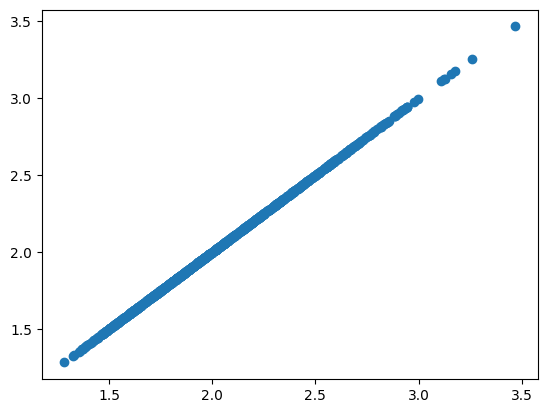

In [149]:
g0 = DeltaGP(
    X1,
    y1, 
    y2_hat, 
    RBF, 
    Zero, 
    noise_var = 1e-8, 
    epsilon = 1e-8, 
    max_cond = 1e6
)

g0.set_params({
    'k_param':jnp.array([ 1.1258382 , 87.03501632, 63.53474934, 53.80366447, 45.6340001 ]),
    'm_param':jnp.array([0., 0., 0., 0.]),
    'noise_var':jnp.array(-16.72645235),
    'rho':jnp.array(0.02904557)
})

plt.scatter(y1, g0.p['rho'] * g1.predict(X1, full_cov = False)[0] + g0.predict(X1, full_cov=False)[0])

In [147]:
optimizer = ADAM(g0, delta_neg_mll, beta1=0.9, beta2=0.999)
optimizer.run(1e-1, 1000, ['k_param', 'noise_var', 'm_param', 'rho'])

100%|██████████| 1000/1000 [01:00<00:00, 16.54it/s, Loss: -6.2580e+03]


{'k_param': Array([ 1.1258382 , 87.03501632, 63.53474934, 53.80366447, 45.6340001 ],      dtype=float64),
 'm_param': Array([0., 0., 0., 0.], dtype=float64),
 'noise_var': Array(-16.52151891, dtype=float64, weak_type=True),
 'rho': Array(0.02904557, dtype=float64, weak_type=True)}

In [166]:
# Taking random sample from each fidelity level
n_hi, n_lo = 5, 100
hf_inds = np.random.choice(1000, size=n_hi, replace=False)
lf_inds = np.random.choice(1000, size=n_lo, replace=False)

X_hf = X1[hf_inds, :]
X_lf = X2[lf_inds, :]

y_hf = y1[hf_inds]
y_lf = y2[lf_inds]



In [167]:
# Defining surrogate models with optimal hyperparameters 
g1 = GP(
    X_lf,
    y_lf, 
    RBF, 
    Linear, 
    max_cond = 1e4,
    noise_var = 1e-8,
    epsilon = 1e-8,
    calibrate=True
)

g1.set_params({
    'k_param':jnp.array([ 4.59231452, 43.95540278, 35.09650143, 50.45847542, 35.22865931]),
    'm_param':jnp.array([16.18080834,  1.81933239,  0.88989751,  3.8881497 ,  4.22606805]),
    'noise_var':jnp.array(-5.93549041)
})

g0 = DeltaGP(
    X_hf,
    y_hf, 
    g1.predict(X_hf, full_cov = False)[0], 
    RBF, 
    Zero, 
    noise_var = 1e-8, 
    epsilon = 1e-8, 
    max_cond = 1e6
)

g0.set_params({
    'k_param':jnp.array([ 1.1258382 , 87.03501632, 63.53474934, 53.80366447, 45.6340001 ]),
    'm_param':jnp.array([0., 0., 0., 0.]),
    'noise_var':jnp.array(-16.72645235),
    'rho':jnp.array(0.02904557)
})

kr = GP(
    X_hf,
    y_hf, 
    RBF, 
    Linear, 
    max_cond = 1e4,
    noise_var = 1e-8, 
    epsilon = 1e-8,
    calibrate=True
)

kr.set_params({
    'k_param':jnp.array([-1.83701895, 37.9111426 , 33.04153796, 29.88139636, 31.08790716]),
    'm_param':jnp.array([2.78745338, 0.13697742, 0.01687562, 0.22625227, 0.30242963]),
    'noise_var':jnp.array(-16.54525245)
})

Calibrated white noise variance: 7.8023e-03
Calibrated white noise variance: 1.0000e-08
Calibrated white noise variance: 1.0000e-08


HK MSE: 7.8383e-02
KR MSE: 2.6510e-02


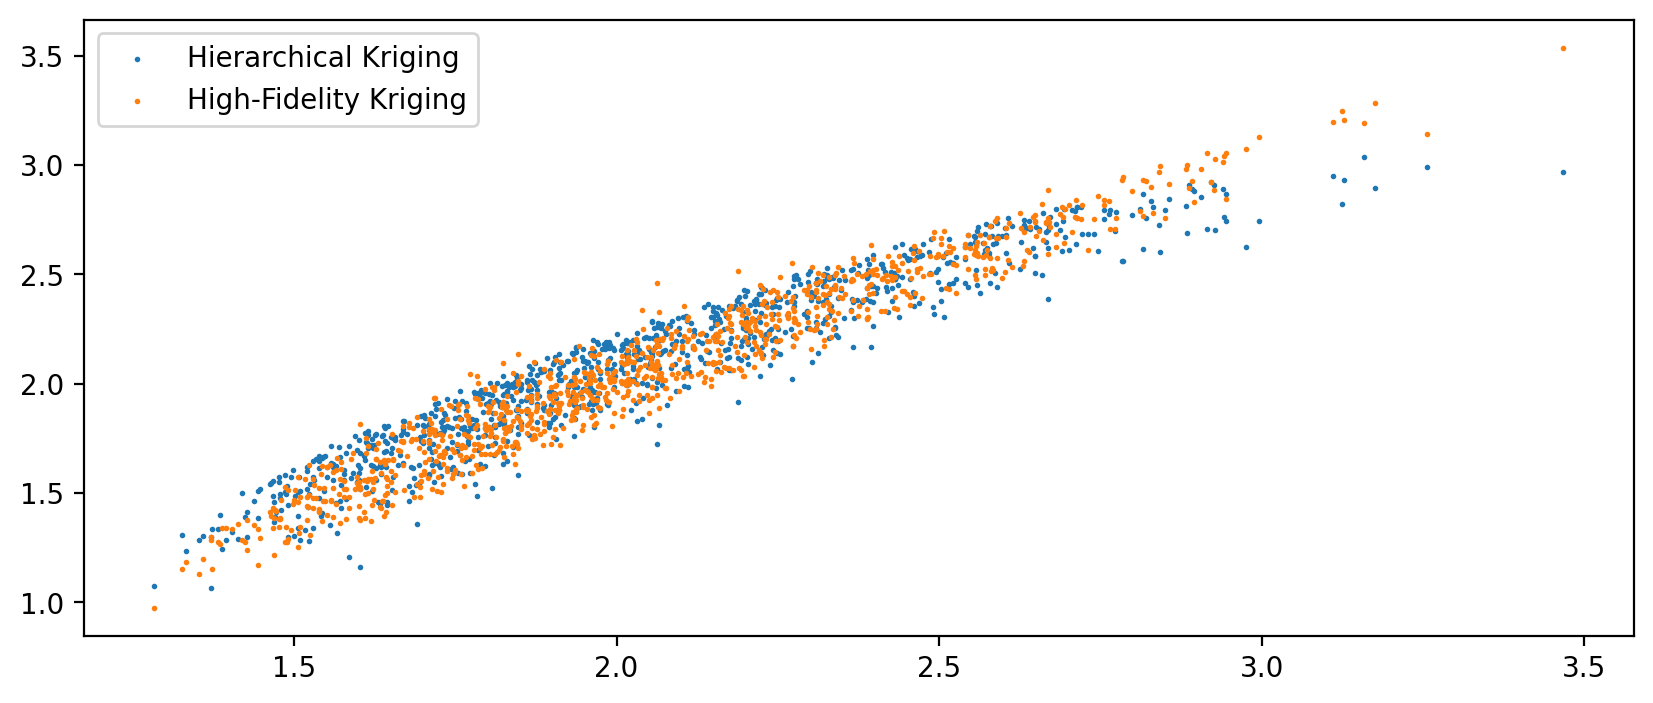

In [168]:
lf_mean, lf_var = g1.predict(X1, full_cov=False)
delta_mean, delta_var = g0.predict(X1, full_cov=False)
hf_mean = g0.p['rho'] * lf_mean + delta_mean 
hf_var = g0.p['rho']**2 * lf_var + delta_var 
kr_mean, kr_var = kr.predict(X1, full_cov=False)

# Computing MSE 
mf_mse = np.mean(hf_var + (hf_mean - y1)**2)
kr_mse = np.mean(kr_var + (kr_mean - y1)**2)
print("HK MSE: %.4e" % (mf_mse))
print("KR MSE: %.4e" % (kr_mse))

plt.figure(figsize=(10,4), dpi=200)
plt.scatter(y1, hf_mean, s = 1, label = "Hierarchical Kriging")
plt.scatter(y1, kr_mean, s = 1, label = "High-Fidelity Kriging")
plt.legend()